# DataTypical v0.7.7 -- Structural-Significance Benchmarks

**Question:** *are formative instances structurally significant?*

This re-does the earlier comparison cleanly:

1. **Like-for-like comparator.** DataTypical's formative score is **model-free and
   label-free**, so the like-for-like comparator is **coreset / facility-location**
   (proper coverage marginal gain). Isolation Forest / influence / KNN-Shapley
   need a model and/or labels and answer a *different* question -- they are kept
   only as clearly-labelled **reference** methods.
2. **Model-free, bounded metrics.** **FLC** (coverage/density) and **kNN
   reconstruction** (fidelity/extent). Retention is normalised as a bounded ratio
   to the full dataset, so it stays in [0, 1] (no impossible sub-zero values). The
   archetype-based ARE is dropped (it was not independent of DataTypical).
3. **Known ground truth + effect sizes + paired tests.** A controlled synthetic
   dataset with known structure-defining corner points lets us validate recovery
   (AUROC). Effect size is a **degradation AUC**; the **significance signal** =
   AUC(remove most-significant first) - AUC(remove least-significant first), mean
   +/- std over seeds, plus **paired per-seed differences** (formative minus each
   baseline) with a one-sided paired t-test. The removal grid has a **fine low
   end (0.2%-5%)** so the few corner points are resolved rather than diluted at
   large n.
4. **Structure vs distraction.** The synthetic data also contain **redundant
   distractor-outlier clusters**: tight clusters placed off the archetype simplex,
   so each point is a textbook density anomaly, yet each is individually
   expendable (its cluster mates pin down the same geometry). A per-instance
   structural-significance score should rank the corners high and the distractors
   low; an anomaly detector flags both. This separates "load-bearing" from
   "merely anomalous".

Figures use **viridis**, legends **outside** the axes, standard (unrotated) tick
labels, and **autoscaled** axes (log scales where values span orders of magnitude).


## Setup

Figures are **shown inline and not saved**; uses a fast synthetic dataset (n=1000). Run from this directory.

In [1]:
import os, sys
# This notebook lives in benchmarks/ alongside the scripts.
HERE = os.path.abspath(".")
PKG_DIR  = os.path.abspath(os.path.join("..", ".."))   # DataTypical/ (datatypical.py)
for p in (HERE, PKG_DIR):
    if p not in sys.path:
        sys.path.insert(0, p)
%matplotlib inline
import common as fc
import exp1_structural_significance as exp1
import exp2_scaling as exp2
import datatypical
fc.apply_rcparams()
print("datatypical:", datatypical.__file__, datatypical.DataTypical().to_config()["version"])

datatypical: C:\Users\Amanda\Favorites\Machine Learning\DataTypical\datatypical.py 0.8.0


## Experiment 1 -- structural significance (synthetic, n=1000)

Recovery of ground-truth structure-defining points (and rejection of redundant distractor outliers), the significance signal (kNN fidelity) with paired per-seed tests, and the degradation curves -- all shown inline.

**How to read the curves, including inversions.** Each score is pruned in *both*
directions: most-significant-first (solid) and least-significant-first (dashed).
A score that captures structural significance degrades faster under
most-significant-first removal (signal > 0) -- formative-archetypal behaves this
way. **An inverted pair (dashed degrading more) is not an artefact**: it means
that score's ranking is *anti-aligned* with structural significance, so the
structure-defining instances sit at the *bottom* of its ranking. The recovery
figure confirms this one-to-one: influence functions recover the ground-truth
corners at AUROC ~0.0, so removing *its* "least significant" instances first
strips exactly those corners and collapses fidelity fastest. The random baseline
shows no direction bias, verifying the pipeline is symmetric.

**Structure vs distraction (recovery figure).** Each scorer gets two AUROCs:
against the structure-defining corners (want high) and against the redundant
distractor outliers (want low). A score that merely detects anomalies scores high
on *both*; a per-instance structural-significance score separates them.

Synthetic (controlled, known structure)  n=1000, seeds=[0, 1, 2, 3, 4]:


  [Synthetic] seed 0 done


  [Synthetic] seed 1 done


  [Synthetic] seed 2 done


  [Synthetic] seed 3 done


  [Synthetic] seed 4 done


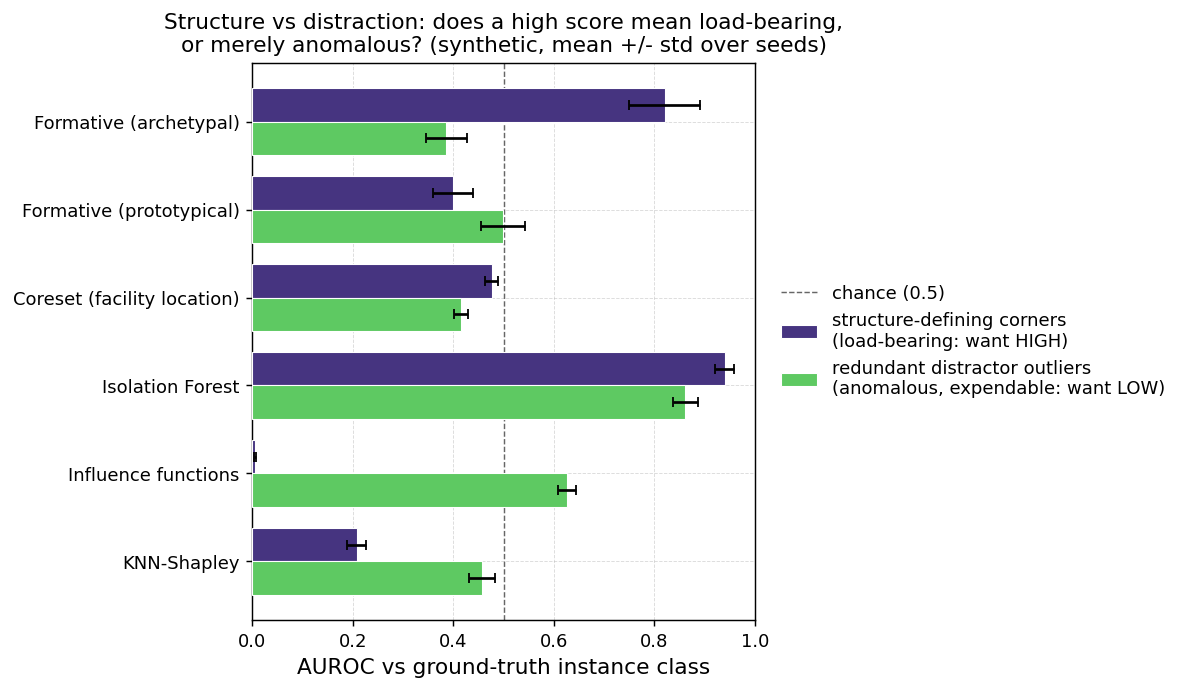

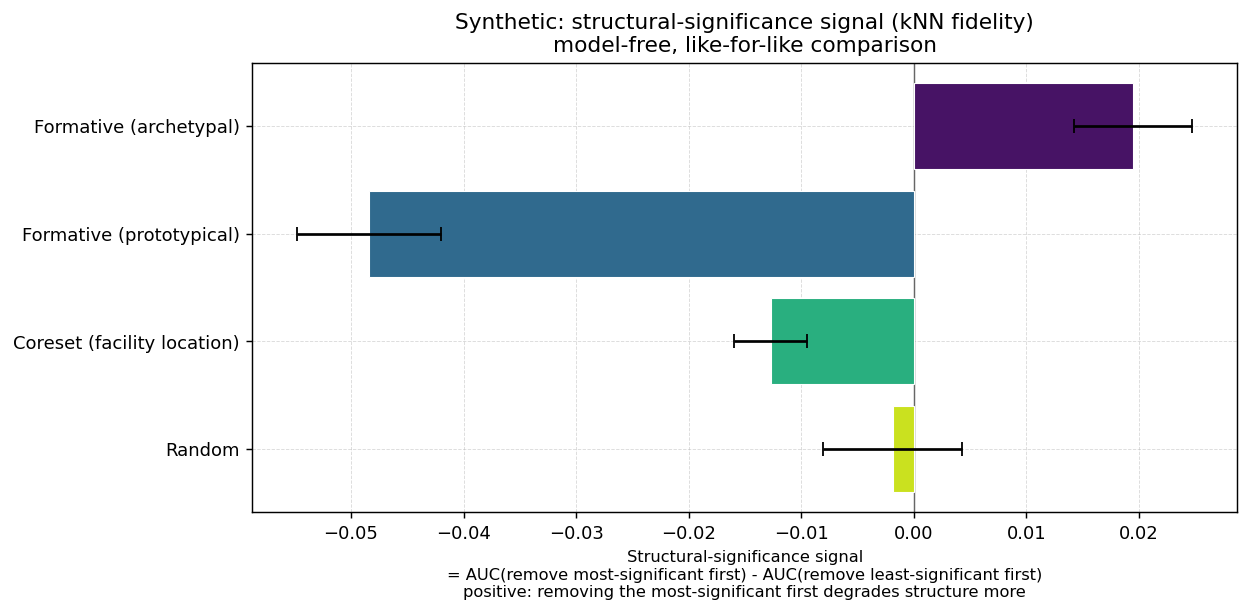

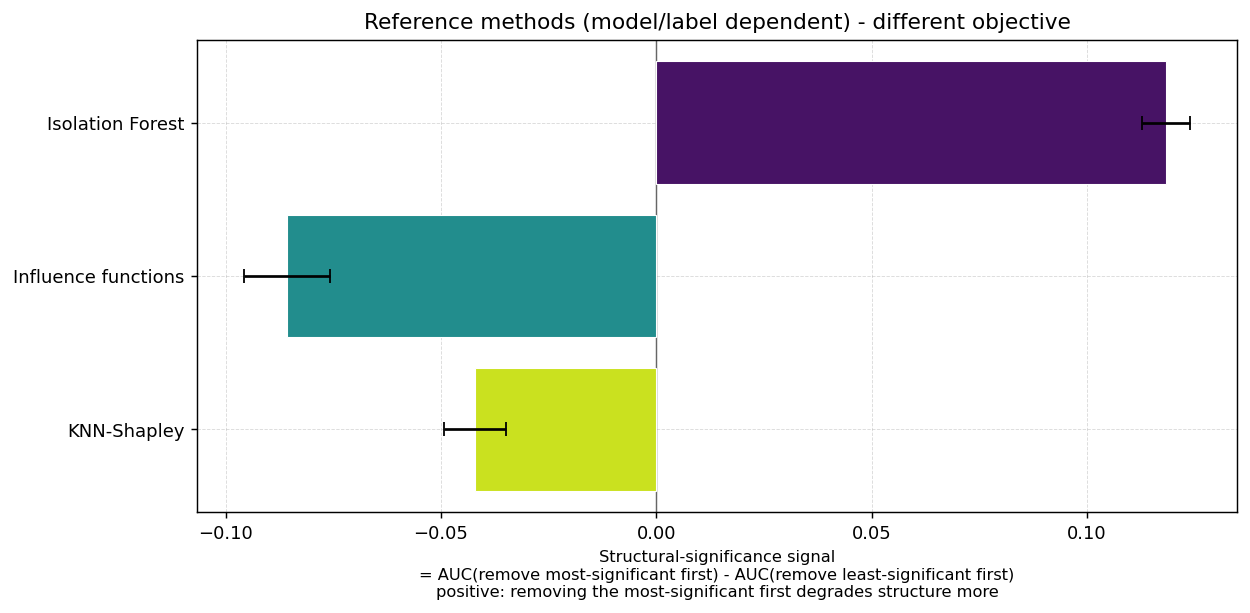

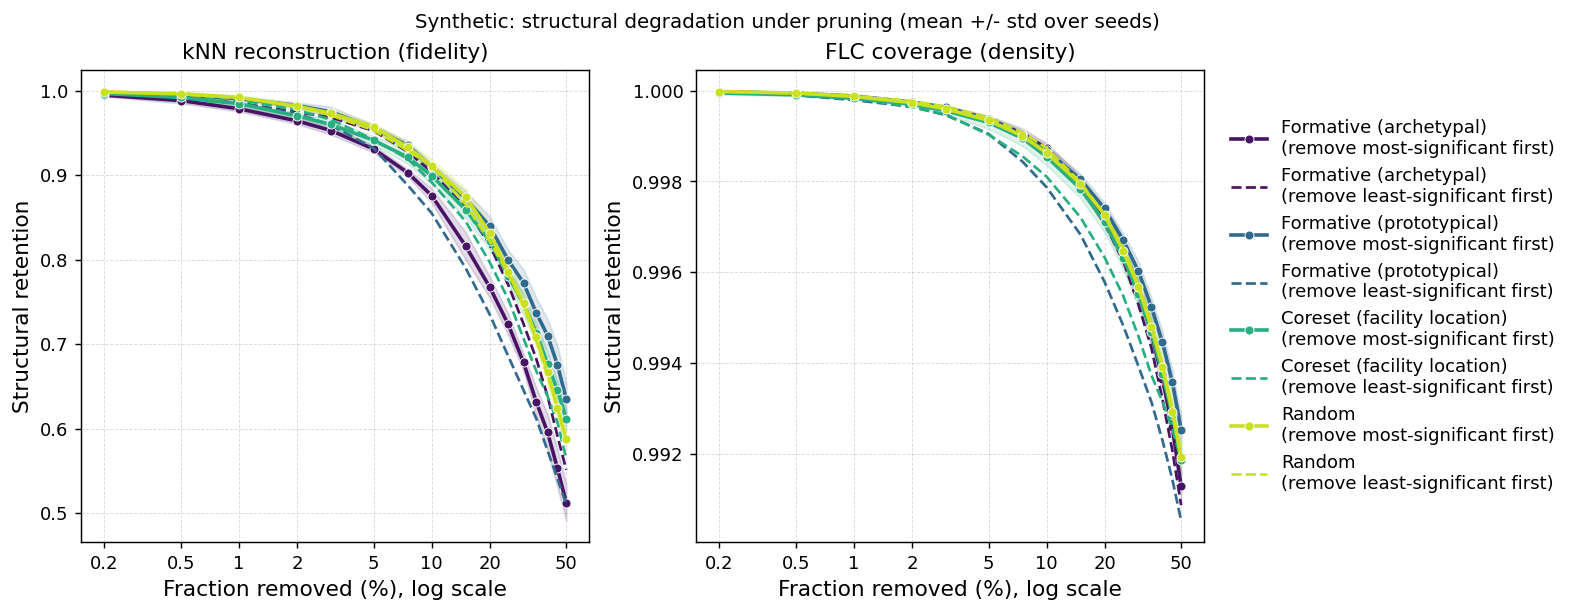


=== Synthetic, kNN fidelity: mean signal +/- std over seeds ===
  [like] Formative (archetypal)     +0.0195 +/- 0.0053
  [like] Formative (prototypical)   -0.0484 +/- 0.0064
  [like] Coreset (facility location) -0.0127 +/- 0.0032
  [like] Random                     -0.0019 +/- 0.0061
  [ref ] Isolation Forest           +0.1183 +/- 0.0056
  [ref ] Influence functions        -0.0858 +/- 0.0099
  [ref ] KNN-Shapley                -0.0421 +/- 0.0072

=== Paired per-seed differences in kNN signal (one-sided paired t-test) ===
  formative_arch - random                mean diff +0.0214 +/- 0.0081  (n=5, t=5.88, p=0.0021)
  formative_arch - coreset               mean diff +0.0322 +/- 0.0067  (n=5, t=10.68, p=0.0002)
  formative_arch - formative_proto       mean diff +0.0679 +/- 0.0096  (n=5, t=15.84, p=0.0000)

=== Structure vs distraction (AUROC, mean over seeds) ===
  Formative (archetypal)     structure 0.820   distractor 0.386
  Formative (prototypical)   structure 0.399   distractor 0.49

In [2]:
exp1.SAVE = False
exp1.SHOW = True
exp1.run(n=1000, seeds=(0, 1, 2, 3, 4))

## Experiment 2 -- formative-step scaling and the v0.7.7 streaming win

Quick grids (the generic path is slow by construction).

vary n (d=8, M=50): streaming vs generic


  n=  500  streaming=  0.004s  generic=   2.368s  (600x)


  n= 1000  streaming=  0.008s  generic=   9.012s  (1154x)


  n= 2000  streaming=  0.018s  generic=  41.593s  (2358x)
vary d (n=1000, M=50): streaming
  d=  2  streaming=  0.005s
  d=  4  streaming=  0.005s
  d=  6  streaming=  0.006s
  d=  8  streaming=  0.008s
  d= 10  streaming=  0.007s
  d= 16  streaming=  0.012s
vary M (n=1000, d=8): streaming vs generic


  M=  10  streaming=  0.004s  generic=   2.362s


  M=  50  streaming=  0.007s  generic=  17.282s


  M= 200  streaming=  0.050s  generic=  73.133s


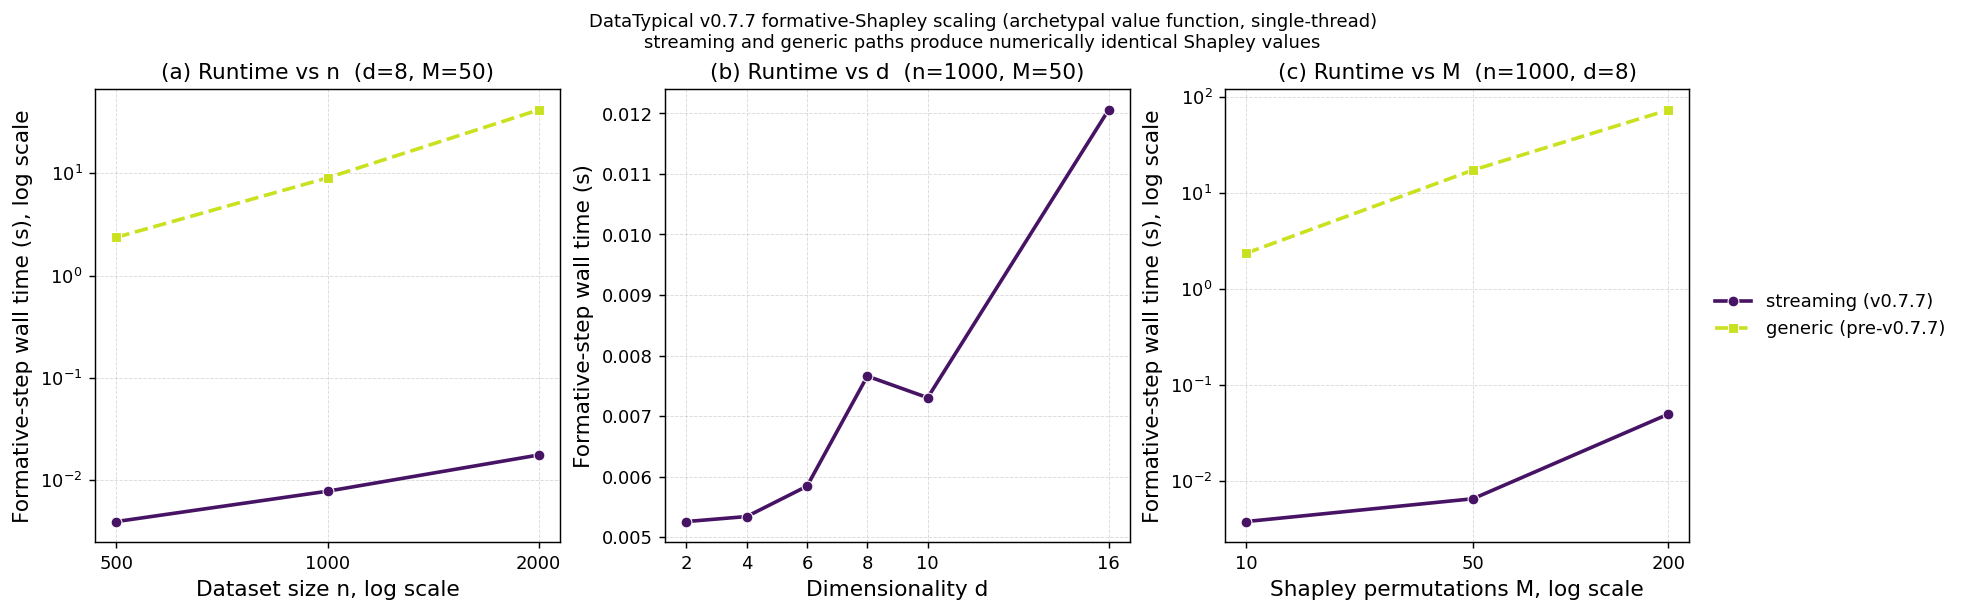

In [3]:
exp2.SAVE = False
exp2.SHOW = True
exp2.run(quick=True)

## Conclusion

**Yes -- archetypal formative instances are structurally significant, in the
fidelity/extent sense.** At this fast scale (n=1000, 5 seeds):

- **Recovery.** Formative-archetypal recovers the ground-truth structure-defining
  corners at AUROC ~0.82 while ranking the redundant distractor outliers *below*
  chance (~0.39).
- **Structure vs distraction.** Isolation Forest finds the corners (~0.94) but also
  flags the distractors (~0.86): it detects *anomalies*, not *load-bearing
  instances*, and cannot tell the two apart. Only the formative score separates
  the classes in the right direction.
- **Significance signal.** Formative-archetypal is the only model-free score with a
  positive signal on the kNN-fidelity metric (~+0.02). The paired per-seed
  differences are significant: vs random p = 0.002, vs coreset p = 0.0002, vs
  prototypical p < 1e-4 (one-sided paired t-tests).

The publication notebook reproduces all of this at n=10,000 with 5 seeds.

Honest qualifications: the effect is **metric-specific** (fidelity/extent, not
coverage/density -- FLC coverage is largely saturated on redundant data); the
signal is small in absolute terms because the structure-defining corners are a
tiny fixed fraction of the data (the fine low end of the removal grid is what
resolves it); and the effect shrinks as data become more redundant (so the
controlled synthetic dataset is the right venue for the claim).